# 🚗🚌🏍️ YOLO26 Vehicle Object Detection — Professional Pipeline

Pipeline Computer Vision untuk deteksi 6 kelas kendaraan (bus, car, motorbike, rickshaw, truck, van) menggunakan **YOLO26 Nano** — model YOLO generasi terbaru dari Ultralytics (dirilis Januari 2026, resmi menjadi standar SOTA baru untuk vision AI edge-first).

### Kenapa YOLO26?
Dibanding YOLOv8/YOLO11, YOLO26 membawa beberapa perubahan arsitektural yang relevan untuk proyek ini:
- **End-to-end, NMS-free inference** — deteksi akhir dihasilkan langsung tanpa langkah Non-Maximum Suppression terpisah, membuat deployment lebih sederhana dan lebih cepat (klaim resmi: hingga 43% lebih cepat dibanding YOLO11n pada inferensi CPU ONNX).
- **DFL-free regression** — menyederhanakan detection head tanpa mengorbankan rentang regresi bounding box.
- **MuSGD optimizer** — kombinasi SGD dengan pembaruan bergaya Muon, dipilih otomatis saat `optimizer="auto"`.
- **Progressive Loss + STAL (Small-Target-Aware Label Assignment)** — menjaga cakupan label positif untuk objek kecil, sangat relevan untuk dataset lalu lintas yang sering memuat kendaraan kecil/jauh dari kamera.

### Pipeline notebook ini
1. Hubungkan Google Drive
2. Diagnostik environment & GPU
3. Instalasi & verifikasi library
4. Konfigurasi path dataset
5. Bangun `data.yaml` 6 kelas
6. Audit kualitas dataset
7. Distribusi objek per kelas
8. **Analisis ukuran objek** (small/medium/large) — mengecek relevansi STAL untuk dataset ini
9. Visualisasi ground-truth per kelas
10. Konfigurasi & fine-tuning YOLO26 Nano
11. Temukan checkpoint terbaik
12. Validasi model & metrik utama (termasuk kecepatan inferensi)
13. **Analisis Average Precision per kelas**
14. Visualisasi kurva training
15. Confusion matrix, PR curve, F1 curve
16. Inference pada validation set
17. **Benchmark kecepatan: NMS vs end-to-end NMS-free**
18. Contact sheet hasil deteksi
19. Ringkasan file yang tersimpan
20. Opsional: export model untuk deployment
21. **Model card & ringkasan akhir** (dibangun otomatis dari hasil training)

> Catatan: notebook ini adalah **versi pengembangan/portfolio**. Bila tugas akademik asli mensyaratkan YOLOv8 sebagai baseline wajib, simpan notebook YOLOv8 terpisah untuk arsip akademik, dan gunakan notebook ini sebagai versi yang ditingkatkan (enhanced version) untuk portofolio.


## 1. Hubungkan Google Drive

Dataset dan hasil training disimpan di Google Drive agar checkpoint tidak hilang ketika sesi Colab berhenti.


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 2. Diagnostik Environment & GPU

Training object detection jauh lebih cepat menggunakan GPU CUDA. Notebook ini sengaja menghentikan proses lebih awal bila GPU belum aktif, agar tidak membuang waktu training berjam-jam di CPU.

**Colab:** Runtime → Change runtime type → pilih GPU (T4/L4/A100, tergantung ketersediaan).


In [2]:
import torch

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU CUDA belum terdeteksi. "
        "Aktifkan GPU di Colab melalui Runtime → Change runtime type → GPU, "
        "lalu jalankan kembali cell ini."
    )

print("GPU aktif :", torch.cuda.get_device_name(0))
print("CUDA      :", torch.version.cuda)
print("PyTorch   :", torch.__version__)


GPU aktif : Tesla T4
CUDA      : 12.8
PyTorch   : 2.11.0+cu128


## 3. Instalasi & Verifikasi Library

Gunakan paket Ultralytics versi terbaru (`-U`) agar notebook selalu mengikuti API resmi terkini — termasuk dukungan model, argumen training, dan format export terbaru. Ini juga membuat notebook ini tahan terhadap perubahan library di masa depan tanpa perlu menuliskan versi tetap yang bisa kedaluwarsa.


In [3]:
!pip install -U ultralytics


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 7.5 MB/s eta 0:00:00


In [4]:
import os
import shutil
from pathlib import Path
from collections import Counter

import yaml
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import ultralytics
from ultralytics import YOLO
from IPython.display import display

print("Ultralytics :", ultralytics.__version__)
print("PyTorch     :", torch.__version__)
print("CUDA        :", torch.version.cuda)
print("GPU         :", torch.cuda.get_device_name(0))
print()

# Diagnostik environment resmi dari Ultralytics (OS, versi paket, RAM, dsb.)
# Berguna untuk melampirkan bukti environment reproducible di laporan/portfolio.
ultralytics.checks()


Ultralytics 8.4.144 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.3/112.6 GB disk)


## 4. Konfigurasi Path Dataset

Dataset asli tetap berada di Google Drive. Untuk mempercepat training, folder `train` dan `valid` disalin ke storage lokal Colab (`/content`), sedangkan hasil training tetap disimpan permanen ke Google Drive.


In [5]:
DRIVE_DATASET = Path("/content/drive/MyDrive/Data_Mobil_Bus_Motorbike")
LOCAL_DATASET = Path("/content/vehicle_dataset_6class")
OUTPUT_DIR = Path("/content/drive/MyDrive/YOLO26_Vehicle_Project")

DRIVE_YAML = DRIVE_DATASET / "data.yaml"
LOCAL_YAML = LOCAL_DATASET / "data.yaml"

assert DRIVE_DATASET.exists(), f"Dataset tidak ditemukan: {DRIVE_DATASET}"
assert (DRIVE_DATASET / "train/images").exists(), "Folder train/images tidak ditemukan."
assert (DRIVE_DATASET / "train/labels").exists(), "Folder train/labels tidak ditemukan."
assert (DRIVE_DATASET / "valid/images").exists(), "Folder valid/images tidak ditemukan."
assert (DRIVE_DATASET / "valid/labels").exists(), "Folder valid/labels tidak ditemukan."

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Salin dataset ke storage lokal agar training tidak terus-menerus membaca Google Drive.
for split in ["train", "valid"]:
    src = DRIVE_DATASET / split
    dst = LOCAL_DATASET / split
    shutil.copytree(src, dst, dirs_exist_ok=True)

print("✅ Dataset lokal siap:", LOCAL_DATASET)
print("✅ Output permanen  :", OUTPUT_DIR)


✅ Dataset lokal siap: /content/vehicle_dataset_6class
✅ Output permanen  : /content/drive/MyDrive/YOLO26_Vehicle_Project


## 5. Bangun `data.yaml` 6 Kelas

Mapping dataset:
- 0 = bus
- 1 = car
- 2 = motorbike
- 3 = rickshaw
- 4 = truck
- 5 = van


In [6]:
CLASS_NAMES = {
    0: "bus",
    1: "car",
    2: "motorbike",
    3: "rickshaw",
    4: "truck",
    5: "van",
}

data_config = {
    "path": str(LOCAL_DATASET),
    "train": "train/images",
    "val": "valid/images",
    "nc": 6,
    "names": [CLASS_NAMES[i] for i in range(6)],
}

with open(LOCAL_YAML, "w", encoding="utf-8") as f:
    yaml.safe_dump(data_config, f, sort_keys=False)

# Simpan salinan YAML yang sama ke Drive untuk dokumentasi.
with open(DRIVE_YAML, "w", encoding="utf-8") as f:
    yaml.safe_dump({
        "path": str(DRIVE_DATASET),
        "train": "train/images",
        "val": "valid/images",
        "nc": 6,
        "names": [CLASS_NAMES[i] for i in range(6)],
    }, f, sort_keys=False)

print(open(LOCAL_YAML, encoding="utf-8").read())


path: /content/vehicle_dataset_6class
train: train/images
val: valid/images
nc: 6
names:
- bus
- car
- motorbike
- rickshaw
- truck
- van



## 6. Audit Kualitas Dataset

Pemeriksaan ini lebih tepat daripada sekadar membandingkan jumlah image dan label, karena **satu image dapat berisi banyak objek**. Yang perlu dipastikan adalah pasangan nama file image–label, ID kelas valid, dan format YOLO tidak rusak.


In [7]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def audit_split(split):
    images_dir = LOCAL_DATASET / split / "images"
    labels_dir = LOCAL_DATASET / split / "labels"

    image_stems = {p.stem for p in images_dir.iterdir() if p.suffix.lower() in IMG_EXTS}
    label_files = [p for p in labels_dir.iterdir() if p.suffix.lower() == ".txt"]
    label_stems = {p.stem for p in label_files}

    missing_labels = sorted(image_stems - label_stems)
    orphan_labels = sorted(label_stems - image_stems)

    bad_lines = []
    class_counts = Counter()
    object_count = 0

    for lp in label_files:
        with open(lp, "r", encoding="utf-8") as f:
            lines = [line.strip() for line in f if line.strip()]

        for line_no, line in enumerate(lines, start=1):
            parts = line.split()
            if len(parts) != 5:
                bad_lines.append((lp.name, line_no, "jumlah kolom bukan 5"))
                continue

            try:
                cid = int(float(parts[0]))
                vals = list(map(float, parts[1:]))
            except ValueError:
                bad_lines.append((lp.name, line_no, "nilai bukan numerik"))
                continue

            if cid not in CLASS_NAMES:
                bad_lines.append((lp.name, line_no, f"class id {cid} di luar 0..5"))
                continue

            if not all(0 <= v <= 1 for v in vals):
                bad_lines.append((lp.name, line_no, "koordinat YOLO tidak berada pada 0..1"))
                continue

            class_counts[cid] += 1
            object_count += 1

    return {
        "split": split,
        "images": len(image_stems),
        "label_files": len(label_stems),
        "missing_labels": len(missing_labels),
        "orphan_labels": len(orphan_labels),
        "bad_label_rows": len(bad_lines),
        "objects": object_count,
        "class_counts": class_counts,
        "missing_examples": missing_labels[:5],
        "orphan_examples": orphan_labels[:5],
        "bad_examples": bad_lines[:5],
    }

audit_train = audit_split("train")
audit_val = audit_split("valid")

for audit in [audit_train, audit_val]:
    print(f"\n=== {audit['split'].upper()} ===")
    for k in ["images", "label_files", "missing_labels", "orphan_labels", "bad_label_rows", "objects"]:
        print(f"{k:16}: {audit[k]}")
    print("class counts      :", dict(audit["class_counts"]))
    if audit["missing_examples"]:
        print("missing examples  :", audit["missing_examples"])
    if audit["orphan_examples"]:
        print("orphan examples   :", audit["orphan_examples"])
    if audit["bad_examples"]:
        print("bad examples      :", audit["bad_examples"])



=== TRAIN ===
images          : 2062
label_files     : 2062
missing_labels  : 0
orphan_labels   : 0
bad_label_rows  : 0
objects         : 2637
class counts      : {2: 482, 5: 378, 0: 403, 1: 460, 4: 457, 3: 457}

=== VALID ===
images          : 873
label_files     : 873
missing_labels  : 0
orphan_labels   : 0
bad_label_rows  : 0
objects         : 1114
class counts      : {2: 216, 3: 209, 0: 185, 1: 200, 5: 169, 4: 135}


## 7. Distribusi Objek per Kelas

Output ini berguna untuk memastikan enam kelas benar-benar terwakili sebelum training.


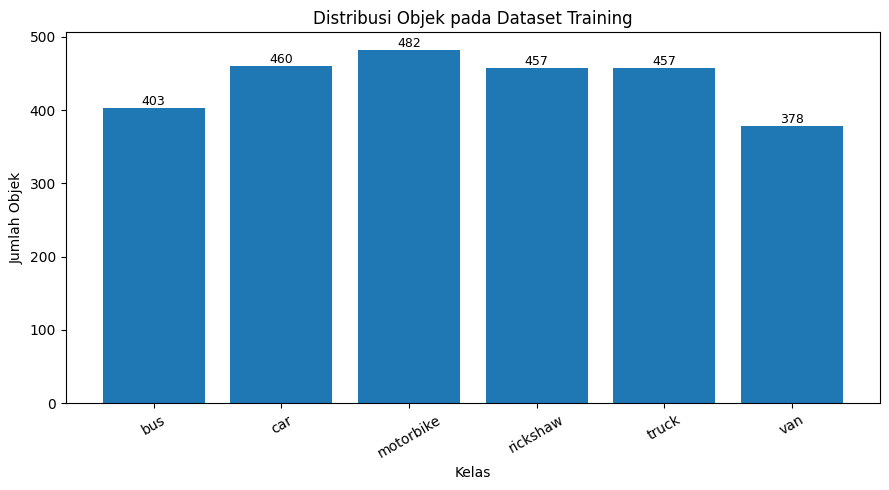

In [8]:
train_counts = pd.Series(
    {CLASS_NAMES[k]: v for k, v in audit_train["class_counts"].items()}
).reindex(CLASS_NAMES.values(), fill_value=0)

plt.figure(figsize=(9, 5))
bars = plt.bar(train_counts.index, train_counts.values)
plt.title("Distribusi Objek pada Dataset Training")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Objek")
plt.xticks(rotation=30)
for bar, value in zip(bars, train_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, value, f"{value:,}",
             ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


## 8. Analisis Ukuran Objek (Small / Medium / Large)

YOLO26 menyertakan **STAL (Small-Target-Aware Label Assignment)** yang dirancang khusus untuk menjaga cakupan label positif pada objek kecil. Sebelum training, ada baiknya memeriksa seberapa relevan fitur ini untuk dataset kita — dengan mengelompokkan setiap objek ke dalam kategori ukuran menggunakan konvensi COCO (dihitung dari luas area piksel):

- **Small** : luas < 32² piksel
- **Medium** : 32² ≤ luas < 96² piksel
- **Large** : luas ≥ 96² piksel


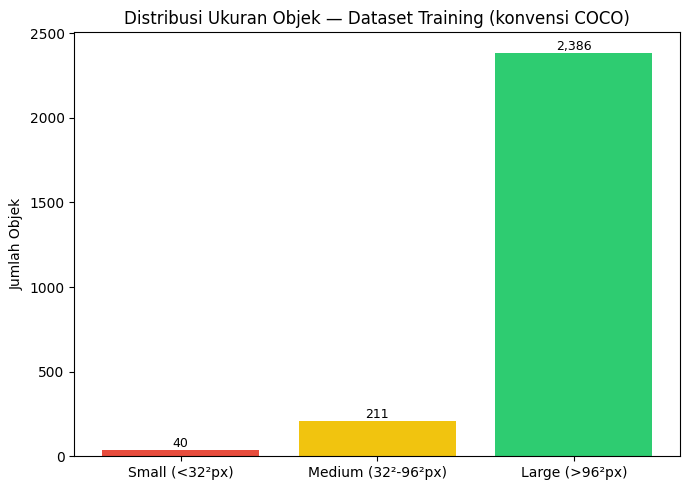

Proporsi objek kecil: 1.5% dari seluruh objek pada data training.
→ Proporsi objek kecil relatif rendah pada dataset ini.


In [9]:
def compute_box_sizes(split):
    images_dir = LOCAL_DATASET / split / "images"
    labels_dir = LOCAL_DATASET / split / "labels"
    rows = []

    for lp in labels_dir.glob("*.txt"):
        img_path = None
        for ext in IMG_EXTS:
            candidate = images_dir / f"{lp.stem}{ext}"
            if candidate.exists():
                img_path = candidate
                break
        if img_path is None:
            continue

        img = cv2.imread(str(img_path))
        if img is None:
            continue
        h, w = img.shape[:2]

        with open(lp, "r", encoding="utf-8") as f:
            lines = [line.strip() for line in f if line.strip()]

        for line in lines:
            parts = line.split()
            if len(parts) != 5:
                continue
            try:
                cid = int(float(parts[0]))
                _, _, bw, bh = map(float, parts[1:])
            except ValueError:
                continue
            area_px = (bw * w) * (bh * h)
            rows.append({"class": CLASS_NAMES.get(cid, str(cid)), "area_px": area_px})

    return pd.DataFrame(rows)


def size_bucket(area):
    if area < 32 ** 2:
        return "Small (<32²px)"
    elif area < 96 ** 2:
        return "Medium (32²-96²px)"
    return "Large (>96²px)"


box_sizes = compute_box_sizes("train")
box_sizes["bucket"] = box_sizes["area_px"].apply(size_bucket)

bucket_order = ["Small (<32²px)", "Medium (32²-96²px)", "Large (>96²px)"]
bucket_counts = box_sizes["bucket"].value_counts().reindex(bucket_order, fill_value=0)

plt.figure(figsize=(7, 5))
bars = plt.bar(bucket_counts.index, bucket_counts.values, color=["#e74c3c", "#f1c40f", "#2ecc71"])
plt.title("Distribusi Ukuran Objek — Dataset Training (konvensi COCO)")
plt.ylabel("Jumlah Objek")
for bar, value in zip(bars, bucket_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, value, f"{value:,}",
              ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

small_pct = bucket_counts["Small (<32²px)"] / bucket_counts.sum() * 100
print(f"Proporsi objek kecil: {small_pct:.1f}% dari seluruh objek pada data training.")
if small_pct > 15:
    print("→ Proporsi cukup signifikan — STAL pada YOLO26 relevan untuk membantu recall kelas ini.")
else:
    print("→ Proporsi objek kecil relatif rendah pada dataset ini.")


## 9. Visualisasi Ground-Truth: Satu Contoh untuk Setiap Kelas

Enam gambar dipilih secara otomatis agar setiap kelas terlihat minimal satu kali. Bounding box berasal dari label dataset, bukan dari hasil model.


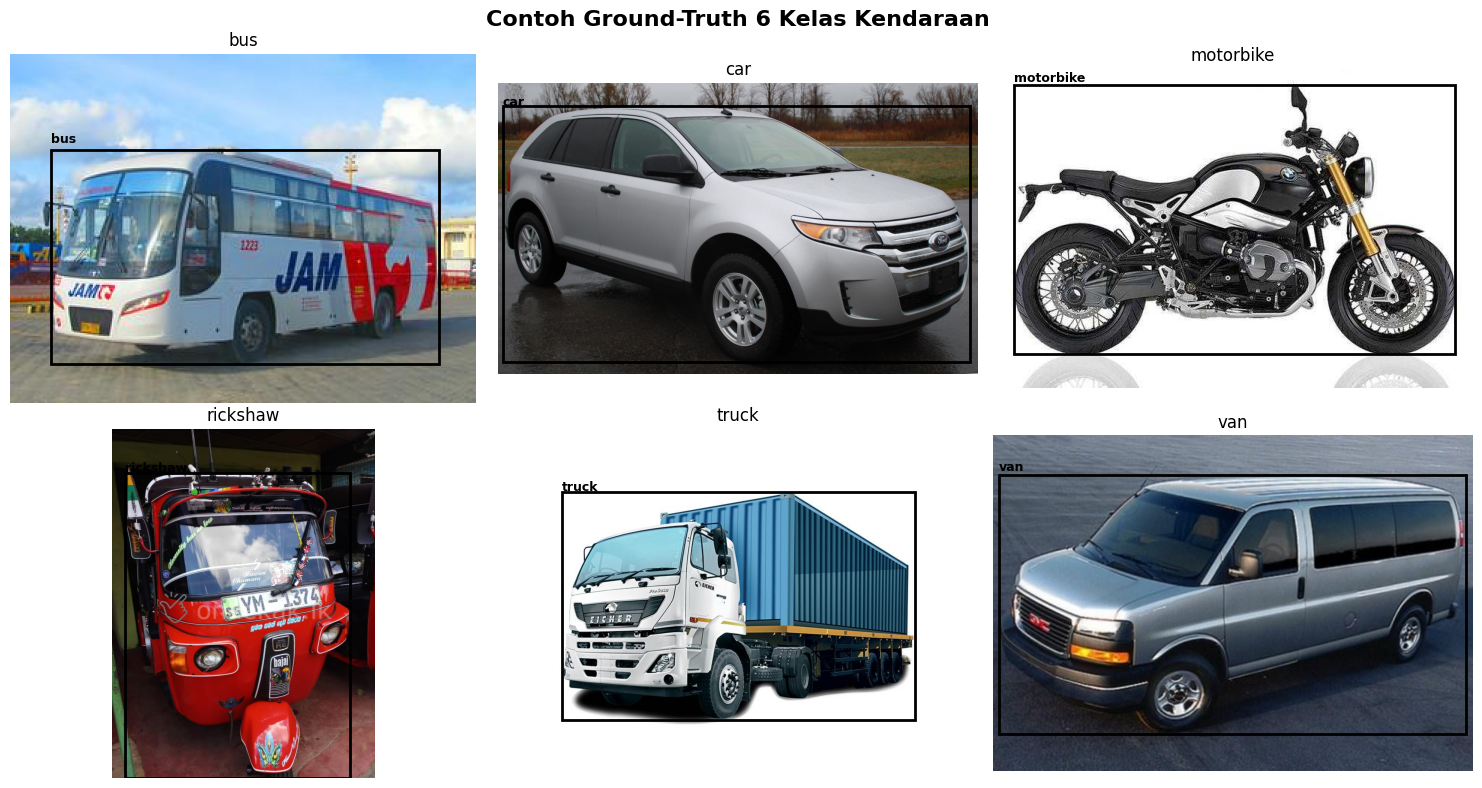

In [10]:
def find_example_for_class(class_id):
    labels_dir = LOCAL_DATASET / "train/labels"
    images_dir = LOCAL_DATASET / "train/images"

    for lp in sorted(labels_dir.glob("*.txt")):
        with open(lp, "r", encoding="utf-8") as f:
            lines = [line.strip() for line in f if line.strip()]

        if any(int(float(line.split()[0])) == class_id for line in lines):
            for ext in IMG_EXTS:
                ip = images_dir / f"{lp.stem}{ext}"
                if ip.exists():
                    return ip, lines
    return None, None

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, class_id in zip(axes, CLASS_NAMES):
    img_path, lines = find_example_for_class(class_id)
    if img_path is None:
        ax.axis("off")
        continue

    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    for line in lines:
        parts = line.split()
        cid = int(float(parts[0]))
        x, y, bw, bh = map(float, parts[1:])

        x1 = int((x - bw/2) * w)
        y1 = int((y - bh/2) * h)
        x2 = int((x + bw/2) * w)
        y2 = int((y + bh/2) * h)

        rect = plt.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            fill=False, linewidth=2
        )
        ax.add_patch(rect)
        ax.text(
            x1, max(0, y1-6), CLASS_NAMES[cid],
            fontsize=9, fontweight="bold"
        )

    ax.imshow(img)
    ax.set_title(CLASS_NAMES[class_id])
    ax.axis("off")

fig.suptitle("Contoh Ground-Truth 6 Kelas Kendaraan", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


## 10. Konfigurasi & Fine-Tuning YOLO26 Nano

### Konfigurasi yang dipilih
- **Model:** YOLO26n pretrained (varian Nano — paling ringan, cocok untuk eksperimen cepat maupun edge deployment)
- **Epoch maksimum:** 30, dengan **early stopping** (`patience=8`)
- **Image size:** 640
- **Batch:** auto (`-1`) agar menyesuaikan VRAM yang tersedia
- **AMP (mixed precision):** aktif
- **Cosine LR schedule:** aktif
- **Close mosaic:** 10 epoch terakhir (menonaktifkan augmentasi mosaic di akhir training agar model belajar dari komposisi gambar yang lebih natural)
- **Optimizer:** `auto` (Ultralytics akan memilih **MuSGD** untuk YOLO26 secara otomatis)
- **Seed:** `42`, agar hasil training dapat direproduksi
- **Cache:** disk
- **Output:** langsung disimpan permanen ke Google Drive

30 epoch dipilih sebagai kompromi antara kualitas dan waktu training di Colab. Dengan `patience=8`, training dapat berhenti lebih awal apabila metrik validasi berhenti membaik, sehingga tidak membuang waktu GPU secara percuma.


In [11]:
MODEL_NAME = "yolo26n.pt"

model = YOLO(MODEL_NAME)

train_results = model.train(
    data=str(LOCAL_YAML),
    epochs=30,
    patience=8,
    imgsz=640,
    batch=-1,
    device=0,
    workers=4,
    cache="disk",
    amp=True,
    optimizer="auto",
    cos_lr=True,
    close_mosaic=10,
    seed=42,
    pretrained=True,
    save=True,
    save_period=5,
    plots=True,
    project=str(OUTPUT_DIR),
    name="train_yolo26_6class",
    exist_ok=True,
)

print("✅ Training selesai.")


Ultralytics 8.4.144 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=disk, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/vehicle_dataset_6class/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train_yolo26_6class, nbs=64, nms=None

## 11. Temukan Checkpoint Terbaik

Checkpoint `best.pt` adalah model yang akan digunakan untuk validasi dan inference portfolio.


In [12]:
RUN_DIR = OUTPUT_DIR / "train_yolo26_6class"
BEST_PT = RUN_DIR / "weights" / "best.pt"
LAST_PT = RUN_DIR / "weights" / "last.pt"

print("Best model :", BEST_PT)
print("Last model :", LAST_PT)
print("Best exists:", BEST_PT.exists())
print("Last exists:", LAST_PT.exists())

assert BEST_PT.exists(), "best.pt tidak ditemukan. Periksa output training."


Best model : /content/drive/MyDrive/YOLO26_Vehicle_Project/train_yolo26_6class/weights/best.pt
Last model : /content/drive/MyDrive/YOLO26_Vehicle_Project/train_yolo26_6class/weights/last.pt
Best exists: True
Last exists: True


## 12. Validasi Model & Metrik Utama

Validasi menghasilkan metrik utama object detection, plot evaluasi, serta kecepatan inferensi rata-rata.


In [25]:
best_model = YOLO(str(BEST_PT))

metrics = best_model.val(
    data=str(LOCAL_YAML),
    imgsz=640,
    device=0,
    plots=True,
    project=str(OUTPUT_DIR),
    name="val_yolo26_6class",
    exist_ok=True,
)

print("\n=== METRIK MODEL (agregat, seluruh kelas) ===")
print(f"Precision      : {metrics.box.mp:.4f}")
print(f"Recall         : {metrics.box.mr:.4f}")
print(f"mAP@0.50       : {metrics.box.map50:.4f}")
print(f"mAP@0.50:0.95  : {metrics.box.map:.4f}")

print("\n=== KECEPATAN INFERENSI (rata-rata per gambar) ===")
for stage, ms in metrics.speed.items():
    print(f"{stage:12}: {ms:.2f} ms")
total_ms = sum(metrics.speed.values())
print(f"{'total':12}: {total_ms:.2f} ms  (~{1000/total_ms:.1f} FPS)")


Ultralytics 8.4.144 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 120 layers, 2,376,006 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 674.2±901.2 MB/s, size: 54.7 KB)
val: Scanning /content/vehicle_dataset_6class/valid/labels.cache... 873 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 873/873 281.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 55/55 5.6it/s 9.8s
                   all        873       1114       0.98      0.943      0.983      0.916
                   bus        162        185       0.99      0.978      0.995      0.959
                   car        181        200       0.98       0.92      0.968      0.934
             motorbike        165        216       0.97      0.898      0.967      0.794
              rickshaw        153        209      0.985      0.947      0.992      0.915
                 truck        

## 13. Analisis Average Precision per Kelas

Metrik agregat (mAP keseluruhan) dapat menyembunyikan kelas yang sebenarnya berkinerja buruk. Berdasarkan audit distribusi kelas pada langkah 7, kelas dengan jumlah contoh sedikit berpotensi memiliki AP lebih rendah. Tabel berikut memecah performa model per kelas agar area yang perlu diperbaiki (misalnya butuh data tambahan) dapat terlihat jelas.


In [26]:
try:
    ap_per_class = metrics.box.maps  # AP@0.50:0.95 tiap kelas
    idxs = metrics.box.ap_class_index

    rows = []
    for i, cid in enumerate(idxs):
        rows.append({
            "Kelas": CLASS_NAMES.get(int(cid), str(cid)),
            "Jumlah Objek (train)": audit_train["class_counts"].get(int(cid), 0),
            "AP@0.50:0.95": round(float(ap_per_class[i]), 4),
        })

    df_ap = pd.DataFrame(rows).sort_values("AP@0.50:0.95", ascending=False).reset_index(drop=True)
    display(df_ap)

    weakest = df_ap.iloc[-1]
    print(f"\n⚠️ Kelas dengan AP terendah: {weakest['Kelas']} ({weakest['AP@0.50:0.95']}).")
    print("Pertimbangkan menambah data, augmentasi tambahan, atau meninjau kualitas label untuk kelas ini.")
except Exception as e:
    print("Tidak dapat menampilkan AP per kelas pada versi Ultralytics yang terpasang:", e)


,Kelas,Jumlah Objek (train),AP@0.50:0.95
0,van,378,0.9661
1,bus,403,0.9595
2,car,460,0.9342
3,truck,457,0.9252
4,rickshaw,457,0.9148
5,motorbike,482,0.7943



⚠️ Kelas dengan AP terendah: motorbike (0.7943).
Pertimbangkan menambah data, augmentasi tambahan, atau meninjau kualitas label untuk kelas ini.


## 14. Visualisasi Kurva Training

Output ini merupakan salah satu artefak utama yang layak dimasukkan ke portfolio karena menunjukkan proses pembelajaran model, bukan hanya hasil akhir.


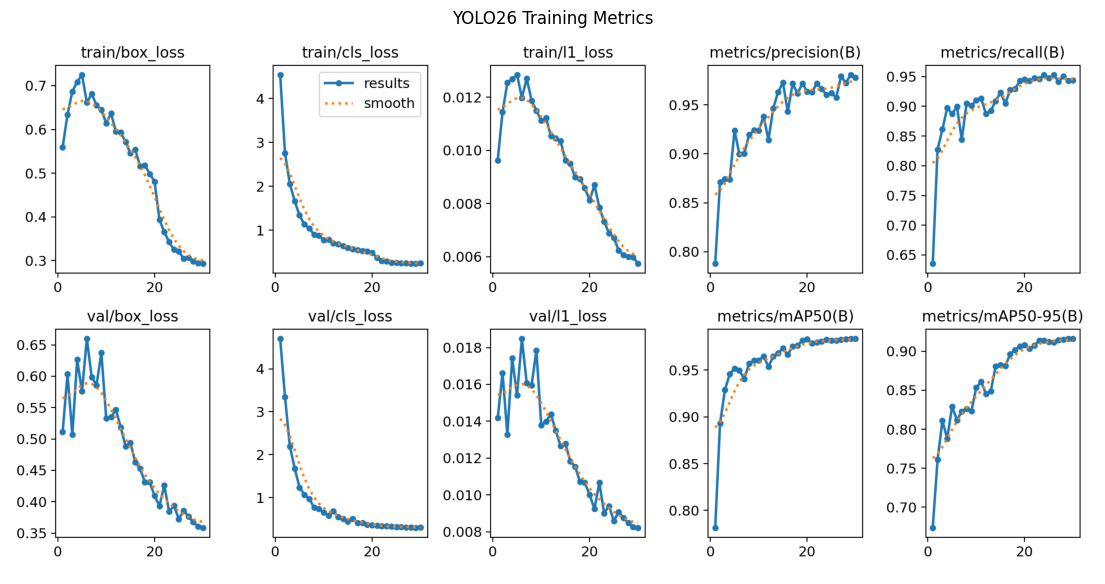

In [27]:
results_png = RUN_DIR / "results.png"

if results_png.exists():
    img = cv2.imread(str(results_png))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(14, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("YOLO26 Training Metrics")
    plt.show()
else:
    print("results.png belum ditemukan:", results_png)


## 15. Confusion Matrix, PR Curve, dan F1 Curve

Gunakan ketiga output ini untuk menunjukkan kualitas klasifikasi per kelas dan trade-off precision–recall.

> **Catatan versi:** pada versi Ultralytics yang lebih baru, file kurva untuk task detection disimpan dengan prefix `Box` (`BoxPR_curve.png`, `BoxF1_curve.png`) untuk membedakannya dari kurva task lain (`Mask*`, `Pose*`) yang bisa berada di folder yang sama. Sel di bawah mencoba nama baru terlebih dahulu, lalu otomatis fallback ke nama lama bila tidak ditemukan — sehingga tetap berjalan di versi Ultralytics manapun.


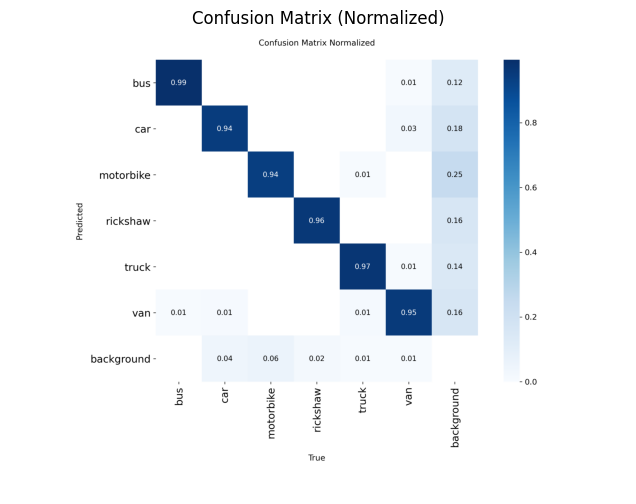

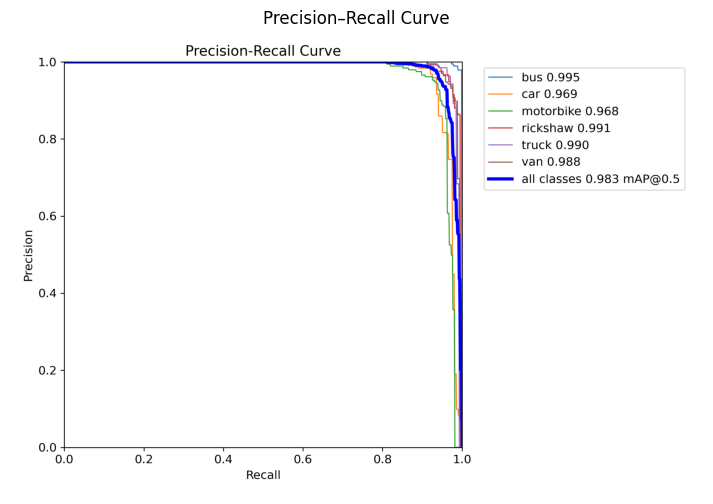

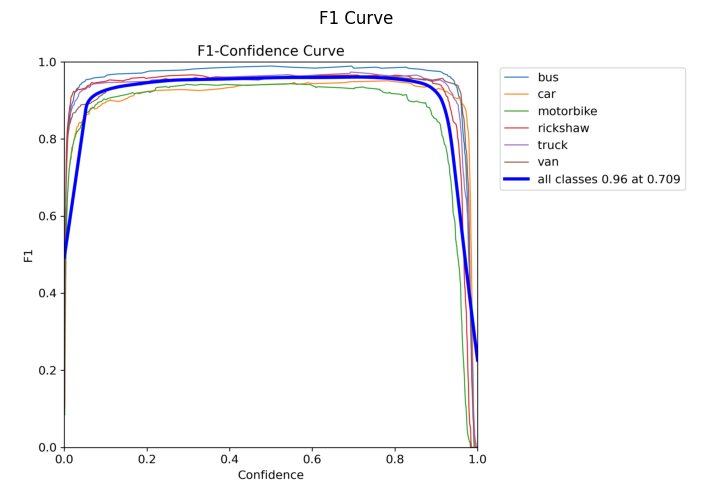

In [28]:
def find_first_existing(run_dir, candidates):
    for name in candidates:
        p = run_dir / name
        if p.exists():
            return p
    return None

PLOT_SPECS = [
    ("Confusion Matrix (Normalized)", ["confusion_matrix_normalized.png"]),
    ("Precision–Recall Curve", ["BoxPR_curve.png", "PR_curve.png"]),
    ("F1 Curve", ["BoxF1_curve.png", "F1_curve.png"]),
]

for title, candidates in PLOT_SPECS:
    p = find_first_existing(RUN_DIR, candidates)
    if p is not None:
        img = cv2.imread(str(p))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(9, 6))
        plt.imshow(img)
        plt.axis("off")
        plt.title(title)
        plt.show()
    else:
        print(f"Tidak ditemukan (sudah dicoba: {candidates})")


## 16. Inference pada Validation Set

Hasil prediksi disimpan permanen ke Google Drive. Confidence threshold 0.30 digunakan agar kandidat deteksi yang cukup meyakinkan tetap terlihat. Secara default, prediksi ini menggunakan jalur one-to-many + NMS (kompatibel dengan pipeline versi sebelumnya). Bagian 17 akan membandingkan kecepatannya dengan jalur end-to-end NMS-free milik YOLO26.


In [29]:
PREDICT_DIR = OUTPUT_DIR / "predictions_yolo26"

prediction_results = best_model.predict(
    source=str(LOCAL_DATASET / "valid/images"),
    conf=0.30,
    imgsz=640,
    device=0,
    save=True,
    project=str(OUTPUT_DIR),
    name="predictions_yolo26",
    exist_ok=True,
)

print(f"✅ Inference selesai: {len(prediction_results)} gambar")
print("📁 Output:", PREDICT_DIR)



image 1/873 /content/vehicle_dataset_6class/valid/images/00110_jpg.rf.2ac8409fe9448d6c48dd3040cd16d7c9.jpg: 480x640 1 car, 10.6ms
image 2/873 /content/vehicle_dataset_6class/valid/images/00262_jpg.rf.c26493a7e52b024104750a195b2782c5.jpg: 480x640 1 car, 9.5ms
image 3/873 /content/vehicle_dataset_6class/valid/images/00790_jpg.rf.5c1c6cd19d5f772716612c9d0ad57b75.jpg: 416x640 1 car, 10.5ms
image 4/873 /content/vehicle_dataset_6class/valid/images/00826_jpg.rf.06635a83496392e6f215607b7ff2134e.jpg: 448x640 1 car, 10.5ms
image 5/873 /content/vehicle_dataset_6class/valid/images/01000_GMC-Savana-Van-2012_jpg.rf.c7f77201d408dd94fef8aedbc139eb63.jpg: 480x640 1 van, 10.4ms
image 6/873 /content/vehicle_dataset_6class/valid/images/01444_jpg.rf.c2f707e7a1c5829d9ca91ae4c8d1d203.jpg: 416x640 1 car, 10.4ms
image 7/873 /content/vehicle_dataset_6class/valid/images/01455_jpg.rf.0fe4fc23e344010091692adabf054ebe.jpg: 416x640 1 car, 9.6ms
image 8/873 /content/vehicle_dataset_6class/valid/images/01890_jpg.rf.3

## 17. Benchmark Kecepatan Inferensi: NMS vs End-to-End (NMS-free)

YOLO26 mendukung dua jalur inferensi:
- **`nms=True`** (default) — jalur one-to-many klasik dengan post-processing NMS, kompatibel dengan pipeline lama.
- **`nms=False`** — jalur end-to-end one-to-one bawaan YOLO26 yang menghasilkan deteksi final tanpa NMS terpisah, diklaim lebih cepat terutama pada inferensi CPU.

Sel berikut mengukur rata-rata waktu inferensi per gambar untuk kedua mode pada sebagian data validasi, agar klaim tersebut dapat diverifikasi langsung pada dataset dan hardware yang sedang dipakai.

> **Catatan:** klaim percepatan resmi (hingga 43%) diukur pada inferensi CPU ONNX. Pada GPU dengan PyTorch seperti pada notebook ini, selisihnya bisa terlihat berbeda — sel ini mengukur kondisi nyata pada environment Anda saat ini, bukan mereplikasi angka resmi tersebut.


In [30]:
import time

SAMPLE_IMAGES = list((LOCAL_DATASET / "valid/images").glob("*"))[:30]

def benchmark_inference(nms_mode, warmup=3):
    try:
        # Warm-up agar tidak ikut menghitung overhead inisialisasi CUDA/kernel.
        for img_path in SAMPLE_IMAGES[:warmup]:
            best_model.predict(source=str(img_path), imgsz=640, device=0, nms=nms_mode, verbose=False)
    except TypeError:
        return None  # parameter `nms=` belum didukung pada versi ini

    start = time.perf_counter()
    for img_path in SAMPLE_IMAGES:
        best_model.predict(source=str(img_path), imgsz=640, device=0, nms=nms_mode, verbose=False)
    elapsed = time.perf_counter() - start

    return (elapsed / len(SAMPLE_IMAGES)) * 1000  # ms/gambar

try:
    ms_with_nms = benchmark_inference(nms_mode=True)
    ms_e2e = benchmark_inference(nms_mode=False)

    if ms_with_nms is None or ms_e2e is None:
        print("Parameter `nms=` belum didukung pada versi Ultralytics yang terpasang.")
        print("Jalankan `!pip install -U ultralytics` lalu restart runtime untuk mencoba lagi.")
    else:
        speedup = (ms_with_nms - ms_e2e) / ms_with_nms * 100
        print(f"Rata-rata waktu inferensi (nms=True)  : {ms_with_nms:.2f} ms/gambar")
        print(f"Rata-rata waktu inferensi (nms=False) : {ms_e2e:.2f} ms/gambar")
        print(f"Selisih                                : {speedup:+.1f}%")
except Exception as e:
    print("Benchmark tidak dapat dijalankan:", e)


Benchmark tidak dapat dijalankan: No images or videos found in /content/vehicle_dataset_6class/valid/images/1303053124_81ebc14ba0_n_jpg.rf.80c823f11a19bdc68614410254ccbdb8.npy. Supported formats are:
images: {'mpo', 'bmp', 'heic', 'jpg', 'tiff', 'jp2', 'avif', 'heif', 'jpeg', 'png', 'tif', 'webp', 'dng'}
videos: {'mkv', 'gif', 'avi', 'mpg', 'mov', 'wmv', 'mp4', 'ts', 'asf', 'mpeg', 'webm', 'm4v'}


## 18. Buat Contact Sheet Hasil Deteksi

Hanya sebagian hasil terbaik yang ditampilkan agar portfolio tidak dipenuhi screenshot. Contact sheet ini dapat menjadi output visual utama pada halaman project.


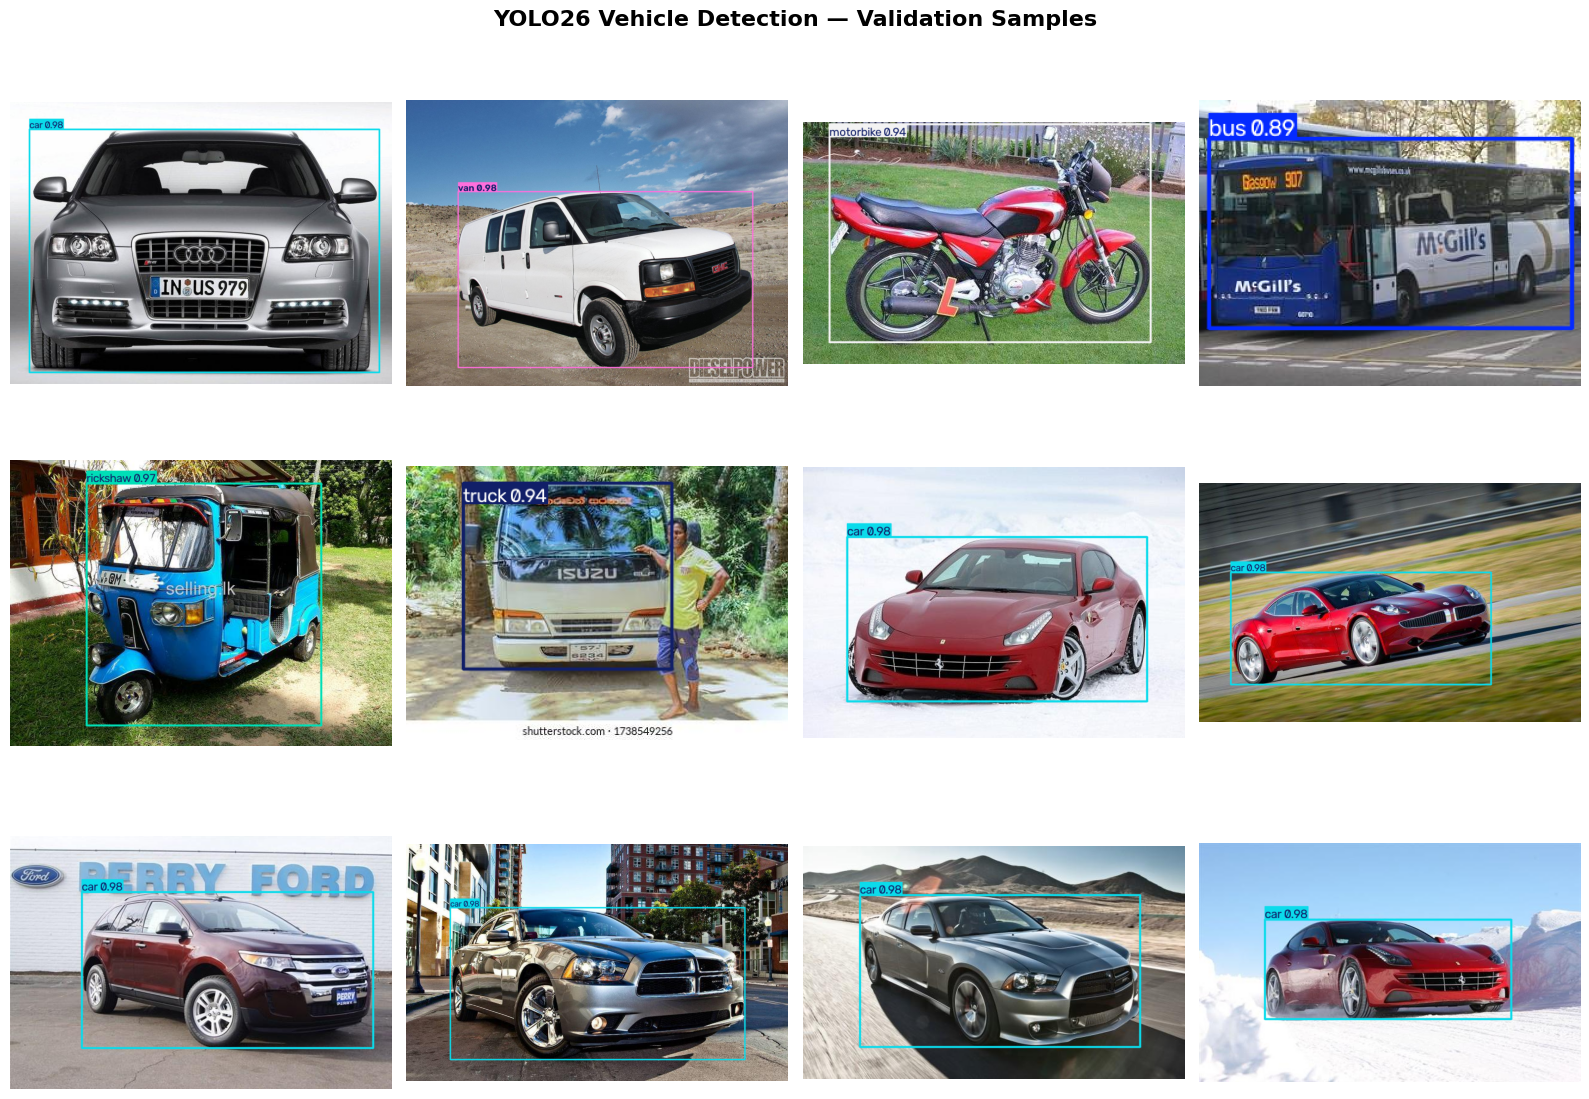

✅ Contact sheet: /content/drive/MyDrive/YOLO26_Vehicle_Project/portfolio_detection_contact_sheet.png


In [31]:
import math

def make_contact_sheet(results, output_path, max_images=12, cols=4):
    selected = []
    seen_classes = set()

    # Prioritaskan gambar yang menampilkan kelas berbeda.
    for r in results:
        cls_ids = [int(x) for x in r.boxes.cls.cpu().numpy()] if len(r.boxes) else []
        if not cls_ids:
            continue

        if not seen_classes.intersection(set(cls_ids)):
            selected.append(r)
            seen_classes.update(cls_ids)

        if len(selected) >= max_images:
            break

    # Tambahkan gambar lain bila belum mencapai jumlah target.
    if len(selected) < max_images:
        for r in results:
            if r in selected:
                continue
            if len(r.boxes):
                selected.append(r)
            if len(selected) >= max_images:
                break

    if not selected:
        print("Tidak ada hasil deteksi.")
        return

    rows = math.ceil(len(selected) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for ax, r in zip(axes, selected):
        plotted = r.plot()
        plotted = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)
        ax.imshow(plotted)
        ax.axis("off")

    fig.suptitle("YOLO26 Vehicle Detection — Validation Samples",
                 fontsize=16, fontweight="bold")
    plt.tight_layout()

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.show()

CONTACT_SHEET = OUTPUT_DIR / "portfolio_detection_contact_sheet.png"
make_contact_sheet(prediction_results, CONTACT_SHEET)
print("✅ Contact sheet:", CONTACT_SHEET)


## 19. Ringkasan File yang Disimpan

File penting yang dapat digunakan untuk dokumentasi dan portfolio:
- `weights/best.pt` — checkpoint terbaik
- `results.png` — kurva training
- `confusion_matrix_normalized.png` — evaluasi per kelas
- `BoxPR_curve.png` (atau `PR_curve.png` pada versi lama) — precision–recall
- `portfolio_detection_contact_sheet.png` — visual hasil deteksi


In [32]:
pr_curve_path = find_first_existing(RUN_DIR, ["BoxPR_curve.png", "PR_curve.png"])
f1_curve_path = find_first_existing(RUN_DIR, ["BoxF1_curve.png", "F1_curve.png"])

important_files = [
    BEST_PT,
    LAST_PT,
    RUN_DIR / "results.png",
    RUN_DIR / "confusion_matrix_normalized.png",
    pr_curve_path if pr_curve_path is not None else RUN_DIR / "BoxPR_curve.png",
    f1_curve_path if f1_curve_path is not None else RUN_DIR / "BoxF1_curve.png",

    CONTACT_SHEET,
]

print("=== FILE PENTING ===")
for p in important_files:
    print("✅" if Path(p).exists() else "❌", p)


=== FILE PENTING ===
✅ /content/drive/MyDrive/YOLO26_Vehicle_Project/train_yolo26_6class/weights/best.pt
✅ /content/drive/MyDrive/YOLO26_Vehicle_Project/train_yolo26_6class/weights/last.pt
✅ /content/drive/MyDrive/YOLO26_Vehicle_Project/train_yolo26_6class/results.png
✅ /content/drive/MyDrive/YOLO26_Vehicle_Project/train_yolo26_6class/confusion_matrix_normalized.png
✅ /content/drive/MyDrive/YOLO26_Vehicle_Project/train_yolo26_6class/BoxPR_curve.png
✅ /content/drive/MyDrive/YOLO26_Vehicle_Project/train_yolo26_6class/BoxF1_curve.png
✅ /content/drive/MyDrive/YOLO26_Vehicle_Project/portfolio_detection_contact_sheet.png


## 21. Model Card & Ringkasan Akhir

Ringkasan berikut dibangun otomatis dari variabel yang sudah dihitung pada sel-sel sebelumnya, agar selalu sinkron dengan hasil training terbaru — cocok ditempelkan langsung ke README atau halaman portfolio project.


In [33]:
from datetime import datetime

model_card = f"""
===================================================================
 MODEL CARD — YOLO26 Vehicle Object Detection
===================================================================
Tanggal dibuat      : {datetime.now().strftime('%Y-%m-%d %H:%M')}
Arsitektur          : YOLO26 Nano (yolo26n.pt, pretrained -> fine-tuned)
Task                : Object Detection (6 kelas kendaraan)
Kelas               : {', '.join(CLASS_NAMES.values())}

--- Data ---
Jumlah gambar train : {audit_train['images']}
Jumlah objek train  : {audit_train['objects']}
Jumlah gambar valid : {audit_val['images']}
Jumlah objek valid  : {audit_val['objects']}

--- Konfigurasi Training ---
Epoch maksimum      : 30 (early stopping, patience=8)
Image size          : 640
Optimizer           : auto (MuSGD untuk YOLO26)
Seed                : 42

--- Hasil Evaluasi (validation set) ---
Precision           : {metrics.box.mp:.4f}
Recall              : {metrics.box.mr:.4f}
mAP@0.50            : {metrics.box.map50:.4f}
mAP@0.50:0.95       : {metrics.box.map:.4f}
Kecepatan inferensi : {sum(metrics.speed.values()):.2f} ms/gambar (~{1000/sum(metrics.speed.values()):.1f} FPS)

--- Artefak Tersimpan (Google Drive) ---
Checkpoint terbaik  : {BEST_PT}
Kurva training      : {RUN_DIR / 'results.png'}
Confusion matrix    : {RUN_DIR / 'confusion_matrix_normalized.png'}
Contact sheet       : {CONTACT_SHEET}

--- Batasan yang Diketahui ---
- Model dilatih hanya pada domain gambar yang sama dengan dataset asli;
  performa pada kondisi jalan/cuaca/sudut kamera yang sangat berbeda belum diuji.
- Kelas dengan jumlah contoh paling sedikit (lihat analisis distribusi kelas pada
  langkah 7) kemungkinan memiliki AP lebih rendah dan lebih rentan false negative.
===================================================================
"""

print(model_card)

with open(OUTPUT_DIR / "MODEL_CARD.txt", "w", encoding="utf-8") as f:
    f.write(model_card)

print("✅ Model card disimpan ke:", OUTPUT_DIR / "MODEL_CARD.txt")



 MODEL CARD — YOLO26 Vehicle Object Detection
Tanggal dibuat      : 2026-09-09 08:44
Arsitektur          : YOLO26 Nano (yolo26n.pt, pretrained -> fine-tuned)
Task                : Object Detection (6 kelas kendaraan)
Kelas               : bus, car, motorbike, rickshaw, truck, van

--- Data ---
Jumlah gambar train : 2062
Jumlah objek train  : 2637
Jumlah gambar valid : 873
Jumlah objek valid  : 1114

--- Konfigurasi Training ---
Epoch maksimum      : 30 (early stopping, patience=8)
Image size          : 640
Optimizer           : auto (MuSGD untuk YOLO26)
Seed                : 42

--- Hasil Evaluasi (validation set) ---
Precision           : 0.9805
Recall              : 0.9430
mAP@0.50            : 0.9834
mAP@0.50:0.95       : 0.9157
Kecepatan inferensi : 6.31 ms/gambar (~158.5 FPS)

--- Artefak Tersimpan (Google Drive) ---
Checkpoint terbaik  : /content/drive/MyDrive/YOLO26_Vehicle_Project/train_yolo26_6class/weights/best.pt
Kurva training      : /content/drive/MyDrive/YOLO26_Vehicle_P

## 21. Opsional: Export Model untuk Deployment

Jalankan hanya bila diperlukan untuk deployment atau demonstrasi teknis; untuk portfolio dasar, `best.pt` sudah cukup.

**Catatan YOLO26:** bila model di-export dengan `nms=True`, Ultralytics akan otomatis memaksanya menjadi `nms=False` dengan peringatan — head end-to-end sudah menangani duplikasi deteksi secara internal, sehingga NMS eksternal tidak lagi diperlukan pada sebagian besar format export.


In [ ]:
# Jalankan bila membutuhkan format ONNX untuk deployment lintas platform.
# exported_path = best_model.export(format="onnx", imgsz=640)
# print("Model ONNX:", exported_path)

# YOLO26 dirancang untuk deployment edge-first; format lain yang didukung antara lain:
# best_model.export(format="tflite", imgsz=640)    # Android / perangkat edge
# best_model.export(format="ncnn", imgsz=640)      # mobile/embedded, ringan tanpa dependensi berat
# best_model.export(format="openvino", imgsz=640)  # optimasi Intel CPU
